# Food Price Prediction Project

Exploratory Data Analysis dan Data Cleaning
Dataset: Harga Pangan Indonesia

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df = pd.read_csv("../data/raw/harga_pangan_2tahun.csv")

df.head()

,ProvID,Provinsi,Tanggal,Komoditas,Nilai,NilaiDiff,SemuaProvinsi,Kelompok,stdDev,Percentage,SemuaPercentage,stdDevPercentage,TanggalLast,TanggalInflasi,show,tanggal
0,2,Sumatera Utara,01 Mar 24,Beras,13800.0,Rp0,15900.0,5,1200.0,0.00,0.0,NaN,29 Feb 24,01 Mar / 29 Feb,True,2024-03-03
1,1,Aceh,01 Mar 24,Beras,13850.0,Rp0,15900.0,5,1200.0,0.00,0.0,NaN,29 Feb 24,01 Mar / 29 Feb,True,2024-03-03
2,26,Sulawesi Selatan,01 Mar 24,Beras,14050.0,Rp50,15900.0,5,1200.0,0.36,0.0,NaN,29 Feb 24,01 Mar / 29 Feb,True,2024-03-03
3,5,Kepulauan Riau,01 Mar 24,Beras,14550.0,Rp0,15900.0,5,1200.0,0.00,0.0,NaN,29 Feb 24,01 Mar / 29 Feb,True,2024-03-03
4,18,Nusa Tenggara Barat,01 Mar 24,Beras,14700.0,Rp0,15900.0,5,1200.0,0.00,0.0,NaN,29 Feb 24,01 Mar / 29 Feb,True,2024-03-03


# Cek Struktur Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23721 entries, 0 to 23720
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ProvID            23721 non-null  int64  
 1   Provinsi          23721 non-null  object 
 2   Tanggal           23721 non-null  object 
 3   Komoditas         23721 non-null  object 
 4   Nilai             23721 non-null  float64
 5   NilaiDiff         23118 non-null  object 
 6   SemuaProvinsi     23721 non-null  float64
 7   Kelompok          23721 non-null  int64  
 8   stdDev            23721 non-null  float64
 9   Percentage        23721 non-null  float64
 10  SemuaPercentage   23721 non-null  float64
 11  stdDevPercentage  0 non-null      float64
 12  TanggalLast       23118 non-null  object 
 13  TanggalInflasi    23118 non-null  object 
 14  show              23721 non-null  bool   
 15  tanggal           23721 non-null  object 
dtypes: bool(1), float64(6), int64(2), object

In [5]:
df.describe()

,ProvID,Nilai,SemuaProvinsi,Kelompok,stdDev,Percentage,SemuaPercentage,stdDevPercentage
count,23721.000000,23721.000000,23721.000000,23721.000000,23721.000000,23721.000000,23721.0,0.0
mean,17.482231,15522.054298,15521.502045,3.651279,1503.703469,-0.000051,0.0,NaN
std,9.808475,1240.957000,269.863136,1.220009,810.587148,0.410344,0.0,NaN
min,1.000000,13150.000000,14150.000000,1.000000,1050.000000,-11.260000,0.0,NaN
25%,9.000000,14600.000000,15300.000000,3.000000,1150.000000,0.000000,0.0,NaN
50%,17.000000,15300.000000,15400.000000,4.000000,1200.000000,0.000000,0.0,NaN
75%,26.000000,16400.000000,15750.000000,5.000000,1300.000000,0.000000,0.0,NaN
max,34.000000,19800.000000,16000.000000,7.000000,7250.000000,12.690000,0.0,NaN


# Visualisasi Harga

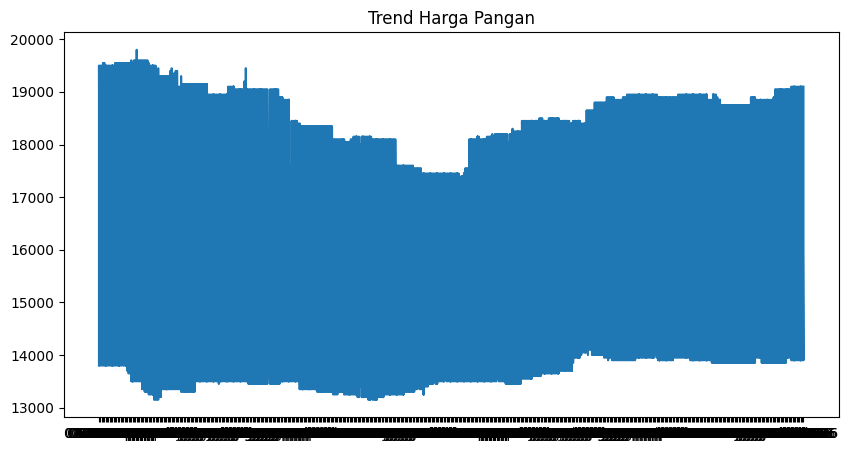

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df["Tanggal"], df["Nilai"])
plt.title("Trend Harga Pangan")
plt.show()

## Filter Data Jawa Timur dan Beras

In [ ]:
df = df[df["Provinsi"] == "Jawa Timur"]
df = df[df["Komoditas"] == "Beras"]

df.head()

,ProvID,Provinsi,Tanggal,Komoditas,Nilai,NilaiDiff,SemuaProvinsi,Kelompok,stdDev,Percentage,SemuaPercentage,stdDevPercentage,TanggalLast,TanggalInflasi,show,tanggal
11,16,Jawa Timur,01 Mar 24,Beras,15400.0,Rp0,15900.0,4,1200.0,0.00,0.0,NaN,29 Feb 24,01 Mar / 29 Feb,True,2024-03-03
42,16,Jawa Timur,04 Mar 24,Beras,15350.0,-Rp50,15950.0,4,1200.0,-0.32,0.0,NaN,01 Mar 24,04 Mar / 01 Mar,True,2024-03-04
76,16,Jawa Timur,05 Mar 24,Beras,15300.0,-Rp50,15950.0,4,1250.0,-0.33,0.0,NaN,04 Mar 24,05 Mar / 04 Mar,True,2024-03-05
110,16,Jawa Timur,06 Mar 24,Beras,15300.0,Rp0,15950.0,4,1250.0,0.00,0.0,NaN,05 Mar 24,06 Mar / 05 Mar,True,2024-03-06
144,16,Jawa Timur,07 Mar 24,Beras,15300.0,Rp0,15950.0,4,1200.0,0.00,0.0,NaN,06 Mar 24,07 Mar / 06 Mar,True,2024-03-07


# Insight yang bisa diambil

Fitur yang diperluka :
1. Tanggal
2. Provinsi
3. Komoditas
4. Nilai
5. NilaiDiff

Harus ngubah Tanggal menjadi datetime karna sebelumnya object (gk bisa diproses)
Handling missing value
Drop duplicate
Sort berdasarkan tanggal (karna sifatnya time series)